<a href="https://colab.research.google.com/github/h3it-dias/NLP_Group_Gradientes_Backpropagation/blob/main/notebooks/Embeddings_Gradientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings e Gradientes

Este notebook junta tudo que está em `embeddings/`: as três formas de aprender
embeddings de palavras (classificador simples, Word2Vec CBOW e Skip-gram) e,
principalmente, o projeto prático sobre **gradiente, regra da cadeia e
`.backward()`** construído em cima delas — um passo mínimo de aprendizado,
uma intervenção, e um exemplo real de uso de embeddings pré-treinados.

## Configuração

Importando o que vamos usar em todo o notebook.

In [1]:
import torch
from torch import nn
import graphviz
import matplotlib.pyplot as plt

torch.manual_seed(0)

## Vocabulário e corpus

Um vocabulário simples (palavra → índice) compartilhado por todos os
modelos, mais um corpus de brinquedo em português usado pelo CBOW e
Skip-gram.

In [2]:
from collections import Counter

UNK_TOKEN = "<unk>"

TOY_CORPUS = [
    "o gato preto dorme no sofa",
    "o cachorro marrom corre no parque",
    "o gato branco brinca com o cachorro",
    "o cachorro late para o gato",
    "o gato mia para o cachorro",
    "a crianca brinca com o cachorro no parque",
    "a crianca brinca com o gato no sofa",
]


def tokenize(text):
    return text.lower().split()


class Vocab:
    def __init__(self, tokens):
        counts = Counter(tokens)
        self.itos = [UNK_TOKEN] + sorted(counts, key=lambda tok: (-counts[tok], tok))
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, token):
        return self.stoi.get(token, self.stoi[UNK_TOKEN])

    def decode(self, index):
        return self.itos[index]


def build_vocab(corpus):
    tokens = [tok for line in corpus for tok in tokenize(line)]
    return Vocab(tokens)


def nearest_neighbors(word, vocab, weights, top_k=5):
    """Rank vocabulary words by cosine similarity to `word`'s embedding."""
    idx = vocab.encode(word)
    target = weights[idx]
    sims = torch.nn.functional.cosine_similarity(weights, target.unsqueeze(0))
    top = torch.topk(sims, min(top_k + 1, len(vocab)))

    results = []
    for score, i in zip(top.values.tolist(), top.indices.tolist()):
        if i == idx:
            continue
        results.append((vocab.decode(i), score))
        if len(results) == top_k:
            break
    return results


vocab_demo = build_vocab(TOY_CORPUS)
print(f"Vocabulário de exemplo: {len(vocab_demo)} palavras")
print(vocab_demo.itos)

Vocabulário de exemplo: 19 palavras
['<unk>', 'o', 'cachorro', 'gato', 'no', 'brinca', 'com', 'a', 'crianca', 'para', 'parque', 'sofa', 'branco', 'corre', 'dorme', 'late', 'marrom', 'mia', 'preto']


## Classificador de sentimento (`nn.EmbeddingBag`)

O uso mais simples de uma camada de embedding: `nn.EmbeddingBag` faz o
lookup e a média das palavras de uma frase de uma vez só, alimentando um
classificador linear (positivo/negativo).

In [3]:
POSITIVE = [
    "eu amo esse filme",
    "o dia esta lindo hoje",
    "que comida deliciosa",
    "estou muito feliz",
    "isso foi otimo",
]
NEGATIVE = [
    "eu odeio esse filme",
    "o dia esta horrivel hoje",
    "que comida horrivel",
    "estou muito triste",
    "isso foi pessimo",
]


class EmbeddingBagClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embedding_dim, mode="mean")
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, tokens, offsets):
        embedded = self.embedding(tokens, offsets)
        return self.classifier(embedded)


def encode_dataset(sentences, vocab):
    """Flatten sentences into one token tensor plus per-sentence start offsets,
    the layout nn.EmbeddingBag expects."""
    tokens, offsets = [], [0]
    for sentence in sentences:
        ids = [vocab.encode(tok) for tok in tokenize(sentence)]
        tokens.extend(ids)
        offsets.append(offsets[-1] + len(ids))
    return torch.tensor(tokens, dtype=torch.long), torch.tensor(offsets[:-1], dtype=torch.long)


def train_sentiment_classifier(epochs=200, embedding_dim=16, lr=0.1, vocab=None, pretrained_embedding=None, verbose=True, log_every=50):
    """Se `pretrained_embedding` for passado (uma tabela vocab_size x
    embedding_dim já treinada em outra tarefa, ex. CBOW), ela substitui a
    inicialização aleatória do nn.EmbeddingBag."""
    sentences = POSITIVE + NEGATIVE
    labels = torch.tensor([1] * len(POSITIVE) + [0] * len(NEGATIVE), dtype=torch.long)
    if vocab is None:
        vocab = build_vocab(sentences)

    tokens, offsets = encode_dataset(sentences, vocab)
    model = EmbeddingBagClassifier(len(vocab), embedding_dim, num_classes=2)
    if pretrained_embedding is not None:
        model.embedding.weight = nn.Parameter(pretrained_embedding.clone())

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(tokens, offsets)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        if verbose and (epoch % log_every == 0 or epoch == 1):
            print(f"epoch {epoch:>3d} | loss {loss.item():.4f}")

    return model, vocab, losses

In [4]:
sentiment_model, sentiment_vocab, sentiment_losses = train_sentiment_classifier(log_every=1)

test_sentences = ["eu amo esse dia", "isso foi horrivel"]
tokens, offsets = encode_dataset(test_sentences, sentiment_vocab)
sentiment_model.eval()
with torch.no_grad():
    preds = sentiment_model(tokens, offsets).argmax(dim=1)
for sentence, pred in zip(test_sentences, preds):
    label = "positivo" if pred.item() == 1 else "negativo"
    print(f'"{sentence}" -> {label}')

epoch   1 | loss 0.8510
epoch   2 | loss 0.8240
epoch   3 | loss 0.7995
epoch   4 | loss 0.7773
epoch   5 | loss 0.7574
epoch   6 | loss 0.7394
epoch   7 | loss 0.7233
epoch   8 | loss 0.7087
epoch   9 | loss 0.6955
epoch  10 | loss 0.6836
epoch  11 | loss 0.6728
epoch  12 | loss 0.6630
epoch  13 | loss 0.6540
epoch  14 | loss 0.6457
epoch  15 | loss 0.6381
epoch  16 | loss 0.6311
epoch  17 | loss 0.6245
epoch  18 | loss 0.6184
epoch  19 | loss 0.6126
epoch  20 | loss 0.6072
epoch  21 | loss 0.6020
epoch  22 | loss 0.5971
epoch  23 | loss 0.5925
epoch  24 | loss 0.5880
epoch  25 | loss 0.5837
epoch  26 | loss 0.5796
epoch  27 | loss 0.5757
epoch  28 | loss 0.5718
epoch  29 | loss 0.5681
epoch  30 | loss 0.5645
epoch  31 | loss 0.5610
epoch  32 | loss 0.5576
epoch  33 | loss 0.5542
epoch  34 | loss 0.5510
epoch  35 | loss 0.5478
epoch  36 | loss 0.5446
epoch  37 | loss 0.5415
epoch  38 | loss 0.5385
epoch  39 | loss 0.5355
epoch  40 | loss 0.5325
epoch  41 | loss 0.5296
epoch  42 | loss

Com 200 linhas de texto fica difícil enxergar a tendência — o gráfico mostra a mesma informação de forma bem mais clara:

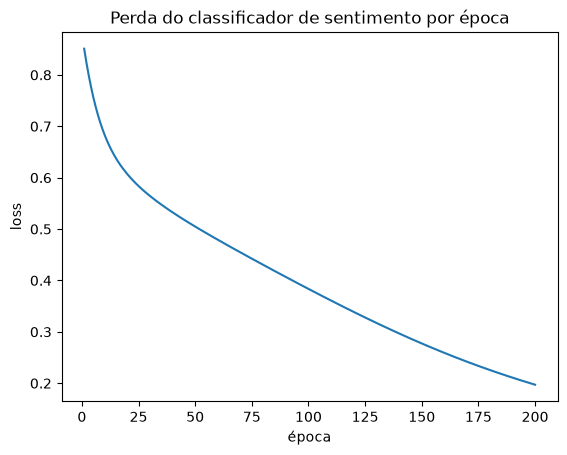

In [5]:
plt.plot(range(1, len(sentiment_losses) + 1), sentiment_losses)
plt.xlabel("época")
plt.ylabel("loss")
plt.title("Perda do classificador de sentimento por época")
plt.show()

## Word2Vec CBOW

Prediz a palavra central a partir das palavras de contexto ao redor dela.

In [6]:
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context):
        # context: (batch, 2 * window) -> average the context embeddings
        embedded = self.embeddings(context).mean(dim=1)
        return self.linear(embedded)


def make_cbow_pairs(corpus, vocab, window=2):
    pairs = []
    for line in corpus:
        tokens = [vocab.encode(tok) for tok in tokenize(line)]
        for i, center in enumerate(tokens):
            context = tokens[max(0, i - window):i] + tokens[i + 1:i + window + 1]
            if len(context) == 2 * window:
                pairs.append((context, center))
    return pairs


def train_cbow(epochs=300, embedding_dim=16, window=2, lr=0.05, corpus=TOY_CORPUS):
    vocab = build_vocab(corpus)
    pairs = make_cbow_pairs(corpus, vocab, window=window)
    contexts = torch.tensor([p[0] for p in pairs], dtype=torch.long)
    centers = torch.tensor([p[1] for p in pairs], dtype=torch.long)

    model = CBOWModel(len(vocab), embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(contexts)
        loss = loss_fn(logits, centers)
        loss.backward()
        optimizer.step()
        if epoch % 50 == 0 or epoch == 1:
            print(f"epoch {epoch:>3d} | loss {loss.item():.4f}")

    return model, vocab

In [7]:
cbow_model, cbow_vocab = train_cbow()
for word in ["gato", "cachorro"]:
    neighbors = nearest_neighbors(word, cbow_vocab, cbow_model.embeddings.weight.detach())
    print(f"vizinhos de '{word}': {neighbors}")

epoch   1 | loss 3.0390
epoch  50 | loss 0.0025
epoch 100 | loss 0.0010
epoch 150 | loss 0.0007
epoch 200 | loss 0.0005
epoch 250 | loss 0.0004
epoch 300 | loss 0.0003
vizinhos de 'gato': [('late', 0.46775898337364197), ('<unk>', 0.32423877716064453), ('mia', 0.295543372631073), ('branco', 0.19912247359752655), ('sofa', 0.1116233766078949)]
vizinhos de 'cachorro': [('mia', 0.4093717932701111), ('late', 0.34827467799186707), ('no', 0.34048545360565186), ('<unk>', 0.2553368806838989), ('parque', 0.24286112189292908)]


## Word2Vec Skip-gram

O inverso do CBOW: prediz cada palavra de contexto a partir da palavra
central.

In [8]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center):
        embedded = self.embeddings(center)
        return self.linear(embedded)


def make_skipgram_pairs(corpus, vocab, window=2):
    pairs = []
    for line in corpus:
        tokens = [vocab.encode(tok) for tok in tokenize(line)]
        for i, center in enumerate(tokens):
            context = tokens[max(0, i - window):i] + tokens[i + 1:i + window + 1]
            pairs.extend((center, ctx) for ctx in context)
    return pairs


def train_skipgram(epochs=300, embedding_dim=16, window=2, lr=0.05, corpus=TOY_CORPUS):
    vocab = build_vocab(corpus)
    pairs = make_skipgram_pairs(corpus, vocab, window=window)
    centers = torch.tensor([p[0] for p in pairs], dtype=torch.long)
    contexts = torch.tensor([p[1] for p in pairs], dtype=torch.long)

    model = SkipGramModel(len(vocab), embedding_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(centers)
        loss = loss_fn(logits, contexts)
        loss.backward()
        optimizer.step()
        if epoch % 50 == 0 or epoch == 1:
            print(f"epoch {epoch:>3d} | loss {loss.item():.4f}")

    return model, vocab

In [9]:
skipgram_model, skipgram_vocab = train_skipgram()
for word in ["gato", "cachorro"]:
    neighbors = nearest_neighbors(word, skipgram_vocab, skipgram_model.embeddings.weight.detach())
    print(f"vizinhos de '{word}': {neighbors}")

epoch   1 | loss 3.1382
epoch  50 | loss 1.7208
epoch 100 | loss 1.7187
epoch 150 | loss 1.7185
epoch 200 | loss 1.7184
epoch 250 | loss 1.7183
epoch 300 | loss 1.7183
vizinhos de 'gato': [('cachorro', 0.2863190770149231), ('crianca', 0.28535425662994385), ('preto', 0.2275848239660263), ('mia', 0.22421027719974518), ('late', 0.1586533784866333)]
vizinhos de 'cachorro': [('mia', 0.33352577686309814), ('gato', 0.2863190770149231), ('brinca', 0.2213079035282135), ('preto', 0.21887871623039246), ('marrom', 0.12763381004333496)]


# Parte 1: passo mínimo de aprendizado

Agora o foco muda: em vez de treinar embeddings úteis, vamos isolar **um
único passo** de treino (forward → loss → backward) na menor rede possível
com embedding, pra observar exatamente o que `.backward()` faz com `.grad`.

A rede: uma palavra vira um vetor de embedding (4 números), que alimenta uma
camada linear com 2 neurônios de saída (2 classes). O forward é feito
**escalar por escalar** — cada multiplicação peso×entrada é sua própria
operação com `.retain_grad()` — em vez de usar `model.linear(embedded)`
de uma vez, exatamente como o `Neuron` do micrograd faz. Isso é bem mais
lento que o jeito normal, mas é o que permite desenhar cada peso e cada
operação como um nó separado no grafo mais adiante.

In [10]:
from dataclasses import dataclass


@dataclass
class LearningStepResult:
    model: "MinimalEmbeddingModel"
    vocab: Vocab
    word: str
    word_id: torch.Tensor
    target_class: int
    embedding_dim: int
    num_classes: int
    neuron_terms: list  # neuron_terms[j][i] = embedding[i] * weight[j][i]
    logits: list  # logits[j], escalar
    probs: torch.Tensor  # (num_classes,), softmax dos logits
    loss: torch.Tensor  # escalar


class MinimalEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, num_classes)

    def forward(self, token_id):
        embedded = self.embedding(token_id)
        return self.linear(embedded)


def print_grad(model, word_id, label):
    """Mostra o .grad de dois parâmetros: a linha da tabela de embedding
    correspondente à palavra usada, e a matriz de pesos da camada linear."""
    embedding_grad = model.embedding.weight.grad
    linear_grad = model.linear.weight.grad

    print(f"[{label}]")
    if embedding_grad is None:
        print("  embedding.weight.grad: None (backward ainda não rodou)")
    else:
        print(f"  embedding.weight.grad (linha da palavra): {embedding_grad[word_id.item()]}")
    if linear_grad is None:
        print("  linear.weight.grad: None (backward ainda não rodou)")
    else:
        print(f"  linear.weight.grad:\n{linear_grad}")


def one_learning_step(word="gato", target_class=1, embedding_dim=4, num_classes=2, lr=0.1):
    """Forward -> loss -> backward -> um passo de otimizador (SGD), pra
    deixar visível a diferença entre o que .backward() faz (só calcula e
    guarda o gradiente em .grad) e o que .step() faz (usa esse gradiente
    pra de fato alterar os pesos)."""
    vocab = build_vocab(TOY_CORPUS)
    torch.manual_seed(0)
    model = MinimalEmbeddingModel(vocab_size=len(vocab), embedding_dim=embedding_dim, num_classes=num_classes)

    word_id = torch.tensor([vocab.encode(word)])

    print_grad(model, word_id, "Antes do backward")

    embedding_row = model.embedding.weight[word_id.item()]

    neuron_terms = []
    logits = []
    for j in range(num_classes):
        terms_j = [embedding_row[i] * model.linear.weight[j, i] for i in range(embedding_dim)]
        for term in terms_j:
            term.retain_grad()

        logit = terms_j[0]
        for term in terms_j[1:]:
            logit = logit + term
        logit = logit + model.linear.bias[j]
        logit.retain_grad()

        neuron_terms.append(terms_j)
        logits.append(logit)

    probs = torch.softmax(torch.stack(logits), dim=0)
    probs.retain_grad()
    loss = -torch.log(probs[target_class])
    loss.retain_grad()

    print(f"\nlogits: {[round(l.item(), 4) for l in logits]}")
    print(f"probs (softmax): {[round(p, 4) for p in probs.detach().tolist()]}")
    print(f"loss: {loss.item():.4f}\n")

    loss.backward()

    print_grad(model, word_id, "Depois do backward")

    embedding_before = model.embedding.weight[word_id.item()].detach().clone()
    linear_row_before = model.linear.weight[0].detach().clone()
    embedding_grad = model.embedding.weight.grad[word_id.item()].detach().clone()
    linear_row_grad = model.linear.weight.grad[0].detach().clone()

    print("\n[Atualização dos pesos]")
    print("  Até aqui, nenhum peso mudou: backward() só preencheu .grad.\n")

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    optimizer.step()

    embedding_after = model.embedding.weight[word_id.item()].detach().clone()
    linear_row_after = model.linear.weight[0].detach().clone()

    print(f"  embedding.weight (linha de '{word}'), lr={lr}")
    print(f"    antes:  {embedding_before}")
    print(f"    grad:   {embedding_grad}")
    print(f"    depois: {embedding_after}\n")

    print(f"  linear.weight[0], lr={lr}")
    print(f"    antes:  {linear_row_before}")
    print(f"    grad:   {linear_row_grad}")
    print(f"    depois: {linear_row_after}\n")

    confere = torch.allclose(embedding_after, embedding_before - lr * embedding_grad) and torch.allclose(
        linear_row_after, linear_row_before - lr * linear_row_grad
    )
    print(f"  Confere? depois == antes - lr * grad  ->  {confere}")

    return LearningStepResult(
        model=model, vocab=vocab, word=word, word_id=word_id, target_class=target_class,
        embedding_dim=embedding_dim, num_classes=num_classes, neuron_terms=neuron_terms,
        logits=logits, probs=probs, loss=loss,
    )

In [11]:
baseline_result = one_learning_step()

[Antes do backward]
  embedding.weight.grad: None (backward ainda não rodou)
  linear.weight.grad: None (backward ainda não rodou)

logits: [0.2722, 0.132]
probs (softmax): [0.535, 0.465]
loss: 0.7657

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
  linear.weight.grad:
tensor([[ 0.0641,  0.6622,  0.5975, -0.1323],
        [-0.0641, -0.6622, -0.5975,  0.1323]])

[Atualização dos pesos]
  Até aqui, nenhum peso mudou: backward() só preencheu .grad.

  embedding.weight (linha de 'gato'), lr=0.1
    antes:  tensor([ 0.1198,  1.2377,  1.1168, -0.2473])
    grad:   tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
    depois: tensor([ 0.1140,  1.2333,  1.1224, -0.2453])

  linear.weight[0], lr=0.1
    antes:  tensor([ 0.3579,  0.1870, -0.4949, -0.3243])
    grad:   tensor([ 0.0641,  0.6622,  0.5975, -0.1323])
    depois: tensor([ 0.3515,  0.1207, -0.5546, -0.3111])

  Confere? depois == antes - lr * grad  ->  True


### Visualizando o grafo

Cada peso, cada componente do embedding e cada multiplicação vira sua
própria caixa (`data`/`grad`), no estilo do `draw_dot` do micrograd — os
dois neurônios de saída aparecem agrupados visualmente.

In [12]:
LEAF_COLOR = "#eef2ff"
ROOT_COLOR = "#d7f5d7"
GRAD_NOT_COMPUTED = "ainda não calculado"


def _scalar(t, decimals=4):
    return f"{t.item():.{decimals}f}"


def gradient_step_graph(result, stage="depois"):
    show_grad = stage != "antes"
    model = result.model
    d = result.embedding_dim
    c = result.num_classes
    embedding_row = model.embedding.weight[result.word_id.item()]
    embedding_row_grad = model.embedding.weight.grad[result.word_id.item()] if model.embedding.weight.grad is not None else None

    def grad_text(t):
        return _scalar(t) if show_grad and t is not None else GRAD_NOT_COMPUTED

    dot = graphviz.Digraph(format="svg", graph_attr={"rankdir": "LR"})
    title = {
        "antes": "Passo mínimo de aprendizado — ANTES do backward",
        "depois": "Passo mínimo de aprendizado — DEPOIS do backward",
        "intervencao": f"Intervenção — target_class={result.target_class}",
    }[stage]
    dot.attr(label=title, labelloc="t", fontsize="16", nodesep="0.35", ranksep="1.1", splines="polyline")
    dot.attr("node", fontname="Helvetica", fontsize="11")
    dot.attr("edge", fontname="Helvetica", fontsize="10")

    def record(node_id, label, value_text, grad_value, fillcolor=None):
        bgcolor = fillcolor or "white"
        html = (
            '<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="4" BGCOLOR="%s">'
            "<TR><TD>%s</TD><TD>data %s</TD><TD>grad %s</TD></TR>"
            "</TABLE>>"
        ) % (bgcolor, label, value_text, grad_text(grad_value))
        dot.node(node_id, html, shape="none")

    def order_top_to_bottom(node_ids, graph=dot):
        with graph.subgraph() as s:
            s.attr(rank="same")
            for node_id in node_ids:
                s.node(node_id)
            for a, b in zip(node_ids, node_ids[1:]):
                s.edge(a, b, style="invis")

    leaf_order = []
    for i in range(d):
        e_i = embedding_row[i]
        e_i_grad = embedding_row_grad[i] if embedding_row_grad is not None else None
        record(f"e{i}", f"e{i} (embedding[\'{result.word}\'][{i}])", _scalar(e_i), e_i_grad, LEAF_COLOR)
        leaf_order.append(f"e{i}")

    for j in range(c):
        for i in range(d):
            leaf_order.append(f"w{j}_{i}")
        leaf_order.append(f"bias{j}")

    for j in range(c):
        for i in range(d):
            w_ji = model.linear.weight[j, i]
            w_ji_grad = model.linear.weight.grad[j, i] if model.linear.weight.grad is not None else None
            record(f"w{j}_{i}", f"w[{j}][{i}]", _scalar(w_ji), w_ji_grad, LEAF_COLOR)

            term = result.neuron_terms[j][i]
            record(f"term{j}_{i}", f"e{i}*w[{j}][{i}]", _scalar(term), term.grad)

            dot.node(f"mul{j}_{i}", "*")
            dot.edge(f"e{i}", f"mul{j}_{i}")
            dot.edge(f"w{j}_{i}", f"mul{j}_{i}")
            dot.edge(f"mul{j}_{i}", f"term{j}_{i}")

        bias_j = model.linear.bias[j]
        bias_j_grad = model.linear.bias.grad[j] if model.linear.bias.grad is not None else None
        record(f"bias{j}", f"linear.bias[{j}]", _scalar(bias_j), bias_j_grad, LEAF_COLOR)

        logit_j = result.logits[j]
        record(f"logit{j}", f"logit[{j}]", _scalar(logit_j), logit_j.grad)

        dot.node(f"sum{j}", "+")
        for i in range(d):
            dot.edge(f"term{j}_{i}", f"sum{j}")
        dot.edge(f"bias{j}", f"sum{j}")
        dot.edge(f"sum{j}", f"logit{j}")

        with dot.subgraph(name=f"cluster_neuron{j}") as cluster:
            cluster.attr(label=f"Neurônio {j} (classe {j})", style="rounded", color="gray50", fontsize="12")
            for i in range(d):
                cluster.node(f"mul{j}_{i}")
                cluster.node(f"term{j}_{i}")
            cluster.node(f"sum{j}")

            order_top_to_bottom([f"mul{j}_{i}" for i in range(d)], graph=cluster)
            order_top_to_bottom([f"term{j}_{i}" for i in range(d)], graph=cluster)

    dot.node("op_softmax", "softmax")
    for j in range(c):
        dot.edge(f"logit{j}", "op_softmax")

    for j in range(c):
        prob_j = result.probs[j]
        prob_j_grad = result.probs.grad[j] if result.probs.grad is not None else None
        fill = ROOT_COLOR if j == result.target_class else None
        record(f"prob{j}", f"prob[{j}]{' (classe alvo)' if j == result.target_class else ''}", _scalar(prob_j), prob_j_grad, fill)
        dot.edge("op_softmax", f"prob{j}")

    dot.node("op_nll", "-log")
    dot.edge(f"prob{result.target_class}", "op_nll")
    record("loss", "loss", _scalar(result.loss), result.loss.grad, ROOT_COLOR)
    dot.edge("op_nll", "loss")

    order_top_to_bottom(leaf_order)
    order_top_to_bottom([f"sum{j}" for j in range(c)])
    order_top_to_bottom([f"logit{j}" for j in range(c)])
    order_top_to_bottom([f"prob{j}" for j in range(c)])

    return dot

**Antes do backward** — todo `grad` ainda é `None`:

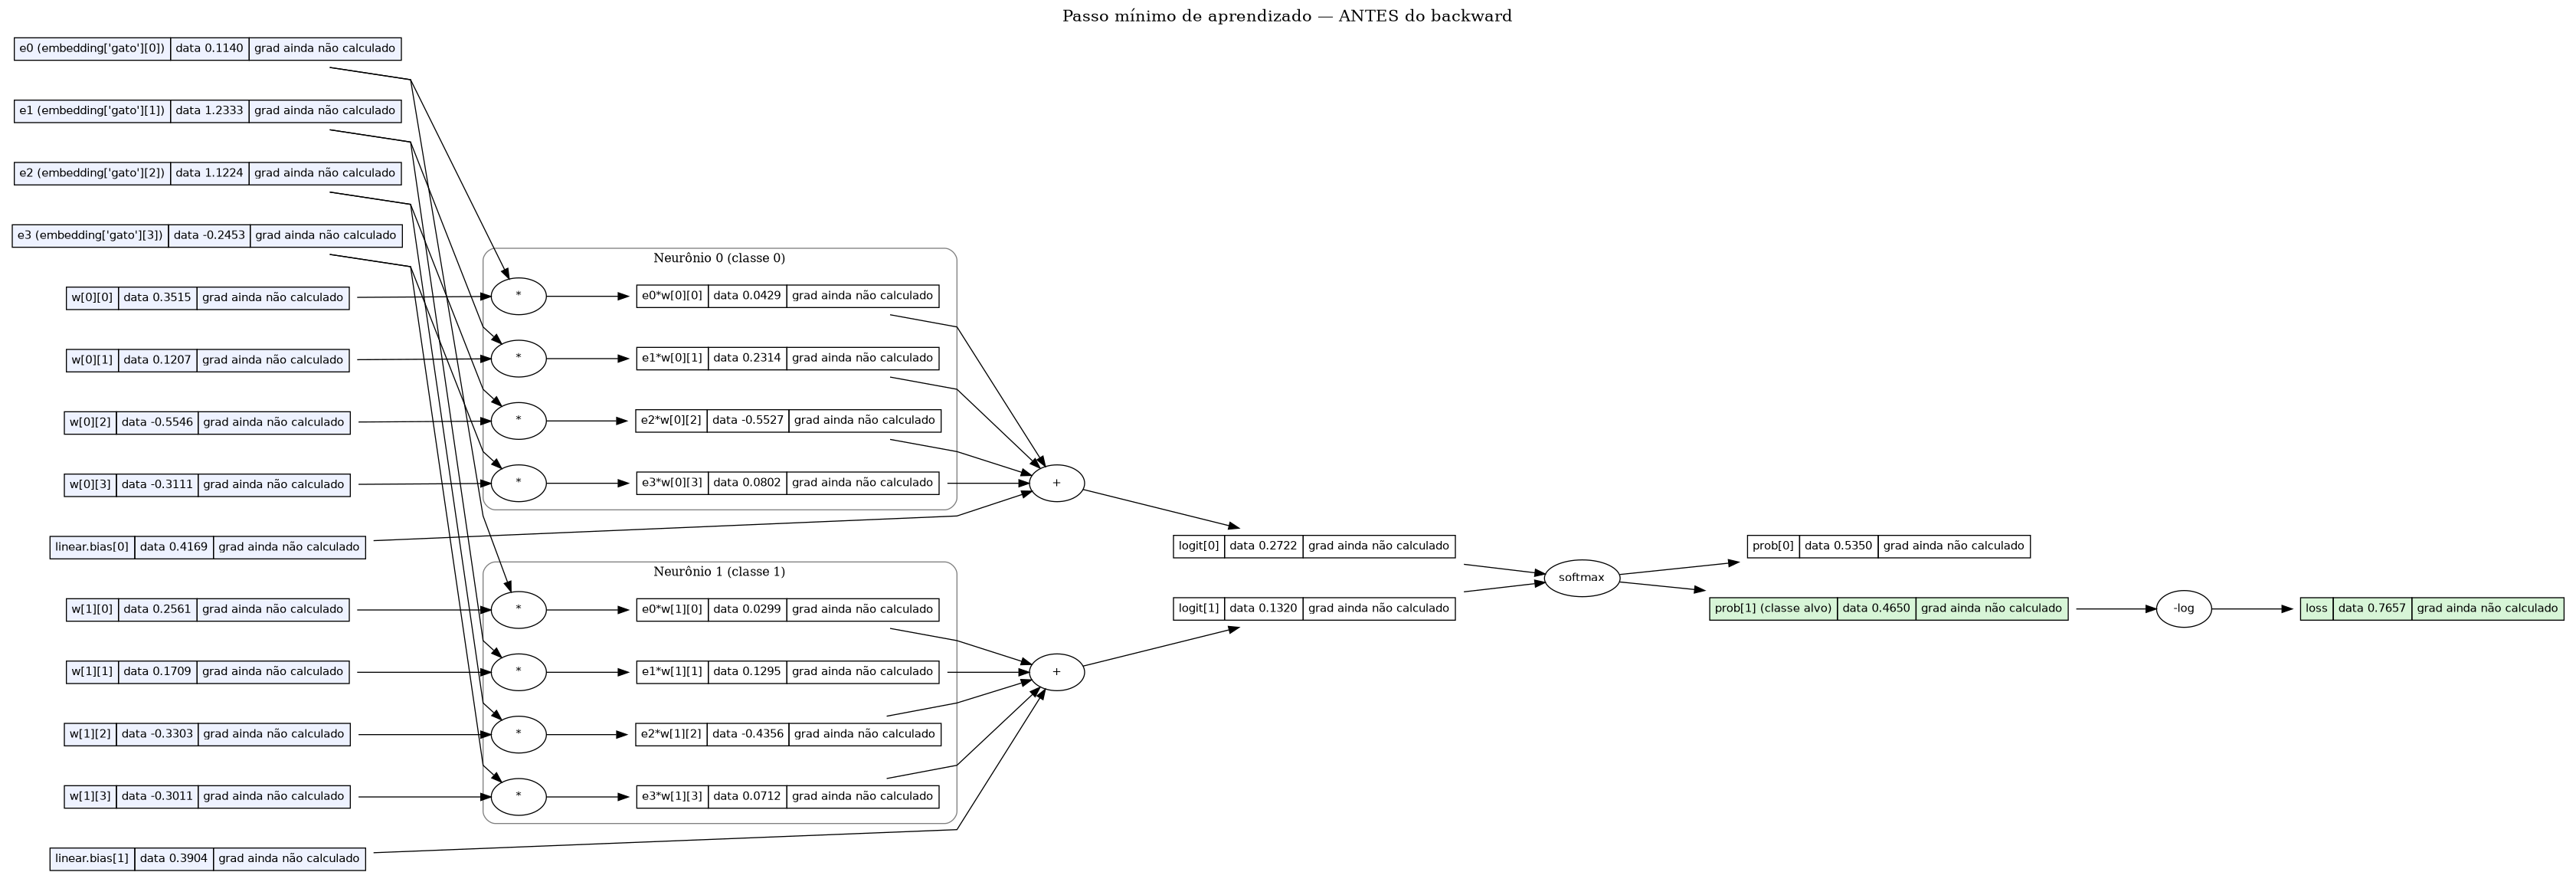

In [13]:
graph_antes = gradient_step_graph(baseline_result, stage='antes')
graph_antes

**Depois do backward** — os gradientes reais, calculados pela regra da cadeia:

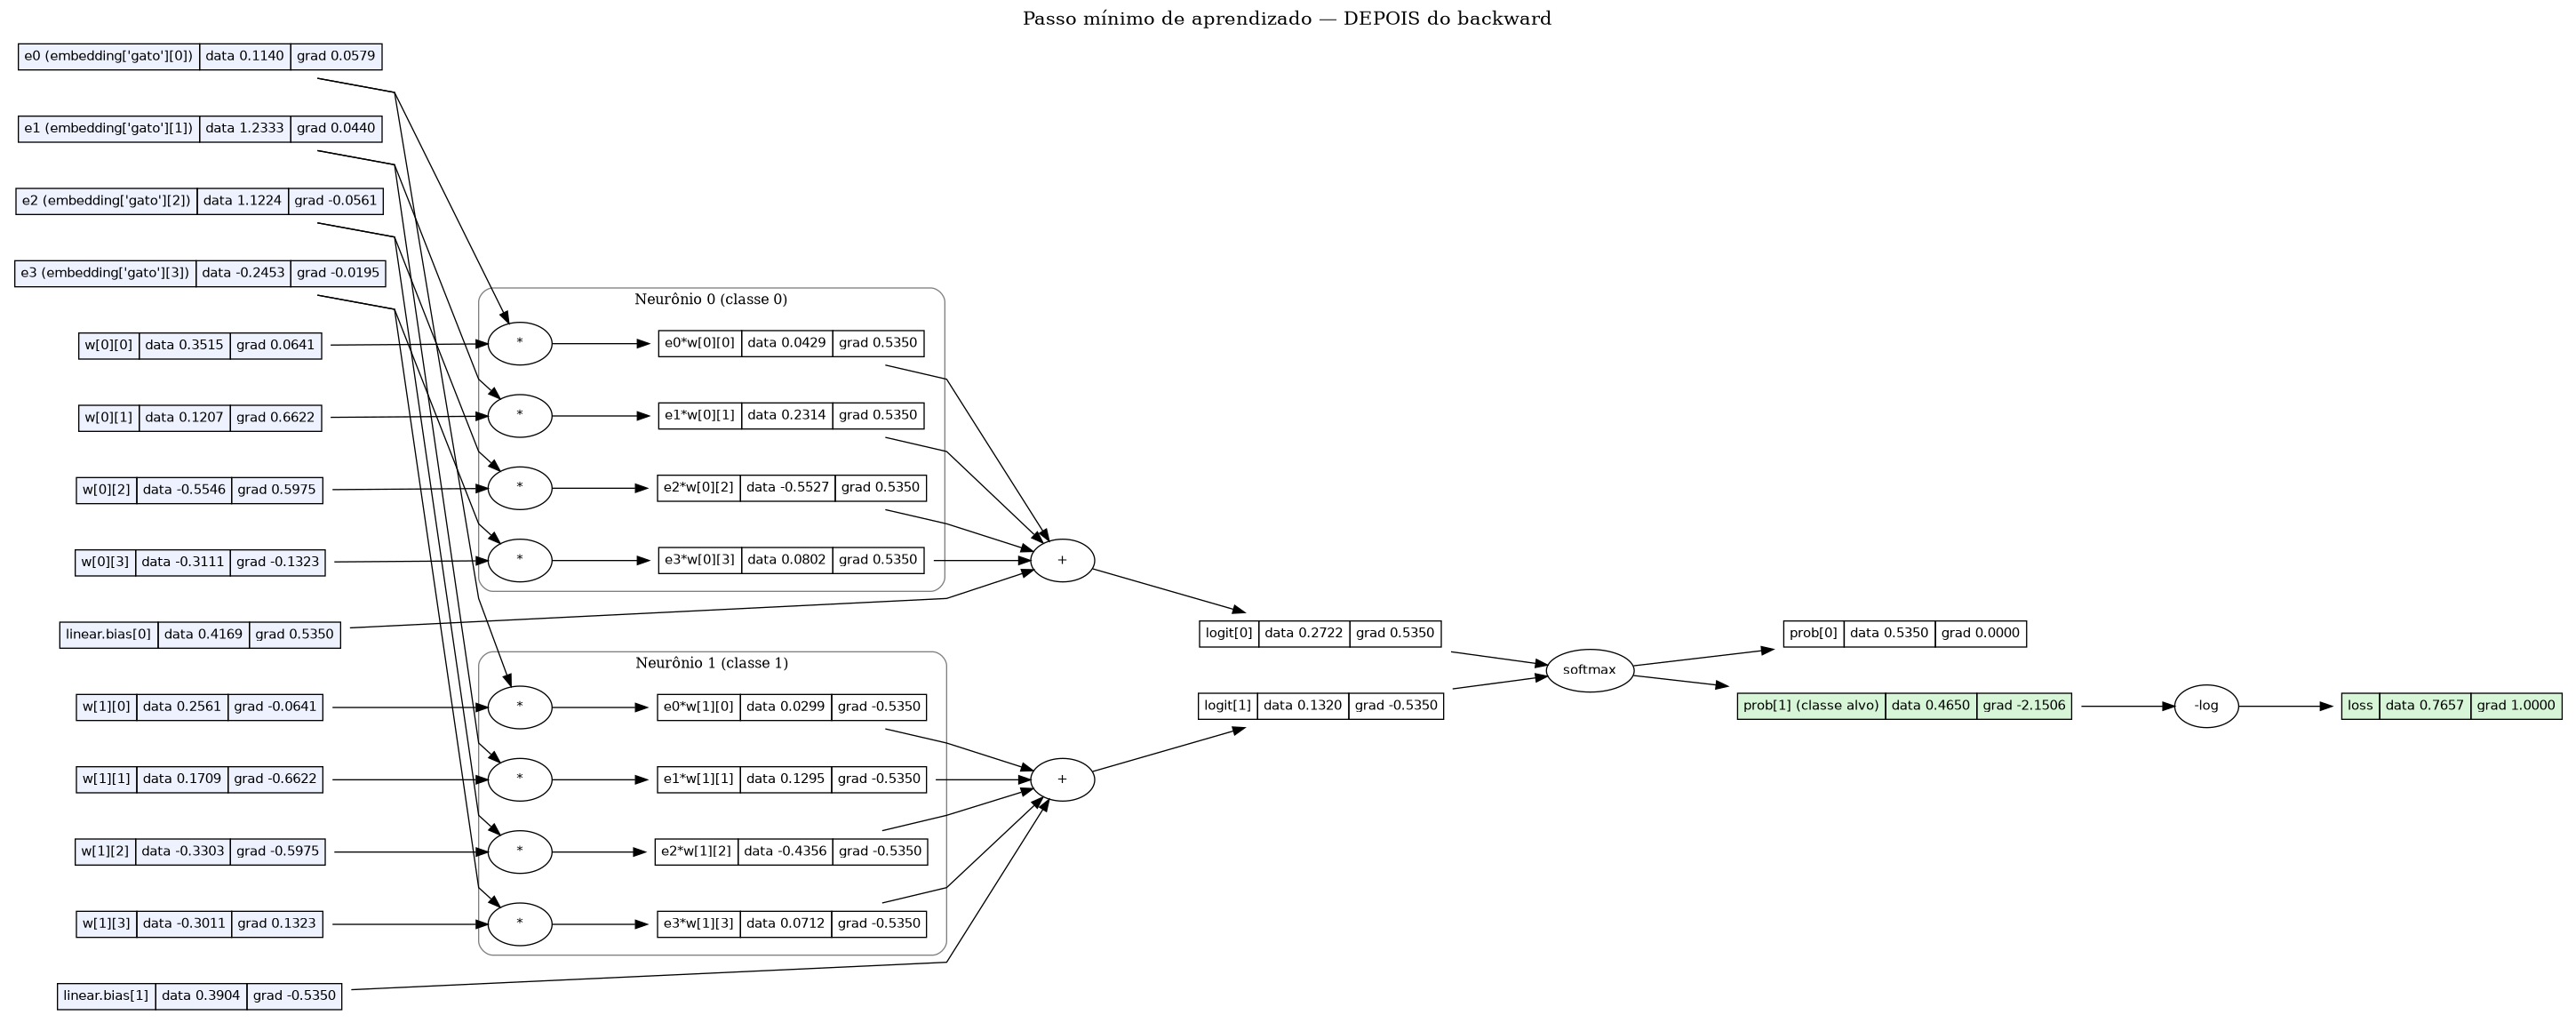

In [14]:
graph_depois = gradient_step_graph(baseline_result, stage='depois')
graph_depois

**Como ler os números:** o gradiente que chega em cada `logit[j]` se
distribui de dois jeitos diferentes ao passar pra trás:
- Pela **soma** (`termo0 + termo1 + termo2 + termo3 + bias`): todo mundo
  recebe o **mesmo** gradiente (regra da soma, derivada = 1 pra cada parcela)
  — por isso os 4 `e_i*w[j][i]` de um mesmo neurônio mostram o mesmo `grad`.
- Pela **multiplicação** (`e_i * w[j][i]`): cada peso recebe o gradiente do
  termo multiplicado pelo *outro* fator (regra do produto) — por isso
  `w[j][i].grad` é diferente para cada `i`, mesmo todos os termos daquele
  neurônio tendo recebido o mesmo gradiente da soma.

# Parte 2: intervenção

Rodando o mesmo exemplo duas vezes com a mesma inicialização de pesos
(`torch.manual_seed(0)` dentro de `one_learning_step`), mudando só o
`target`: uma vez classe 1 (baseline), outra vez classe 0 (intervenção).

In [15]:
def intervention_demo(word="gato", baseline_target=1, new_target=0):
    print(f"########## BASELINE (target_class={baseline_target}) ##########")
    baseline = one_learning_step(word=word, target_class=baseline_target)

    print(f"\n########## INTERVENÇÃO (target_class={new_target}) ##########")
    intervened = one_learning_step(word=word, target_class=new_target)

    print("\n########## COMPARAÇÃO ##########")
    print(f"probs (baseline):    {[round(p, 4) for p in baseline.probs.detach().tolist()]}")
    print(f"probs (intervenção): {[round(p, 4) for p in intervened.probs.detach().tolist()]}")
    print(f"loss (baseline):     {baseline.loss.item():.4f}")
    print(f"loss (intervenção):  {intervened.loss.item():.4f}\n")

    print(f"{'':22s}{'baseline':>12s}{'intervenção':>14s}")
    base_emb_grad = baseline.model.embedding.weight.grad[baseline.word_id.item()]
    interv_emb_grad = intervened.model.embedding.weight.grad[intervened.word_id.item()]
    for i in range(baseline.embedding_dim):
        print(f"embedding.grad[{i}]{'':6s}{base_emb_grad[i].item():>12.4f}{interv_emb_grad[i].item():>14.4f}")

    for j in range(baseline.num_classes):
        for i in range(baseline.embedding_dim):
            g1 = baseline.model.linear.weight.grad[j, i].item()
            g2 = intervened.model.linear.weight.grad[j, i].item()
            print(f"w[{j}][{i}].grad{'':7s}{g1:>12.4f}{g2:>14.4f}")

    return baseline, intervened


baseline_result, intervened_result = intervention_demo()

########## BASELINE (target_class=1) ##########
[Antes do backward]
  embedding.weight.grad: None (backward ainda não rodou)
  linear.weight.grad: None (backward ainda não rodou)

logits: [0.2722, 0.132]
probs (softmax): [0.535, 0.465]
loss: 0.7657

[Depois do backward]
  embedding.weight.grad (linha da palavra): tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
  linear.weight.grad:
tensor([[ 0.0641,  0.6622,  0.5975, -0.1323],
        [-0.0641, -0.6622, -0.5975,  0.1323]])

[Atualização dos pesos]
  Até aqui, nenhum peso mudou: backward() só preencheu .grad.

  embedding.weight (linha de 'gato'), lr=0.1
    antes:  tensor([ 0.1198,  1.2377,  1.1168, -0.2473])
    grad:   tensor([ 0.0579,  0.0440, -0.0561, -0.0195])
    depois: tensor([ 0.1140,  1.2333,  1.1224, -0.2453])

  linear.weight[0], lr=0.1
    antes:  tensor([ 0.3579,  0.1870, -0.4949, -0.3243])
    grad:   tensor([ 0.0641,  0.6622,  0.5975, -0.1323])
    depois: tensor([ 0.3515,  0.1207, -0.5546, -0.3111])

  Confere? depois == 

Como o forward é idêntico (mesmos pesos, mesma palavra), `logits` e `probs` não mudam — só a `loss` e os gradientes, que trocam de sinal (não exatamente, já que as probabilidades não são simétricas). Isso é esperado: para cross-entropy com softmax, `∂loss/∂logit_j = prob[j] - 1` se `j` for a classe alvo, ou só `prob[j]` caso contrário.

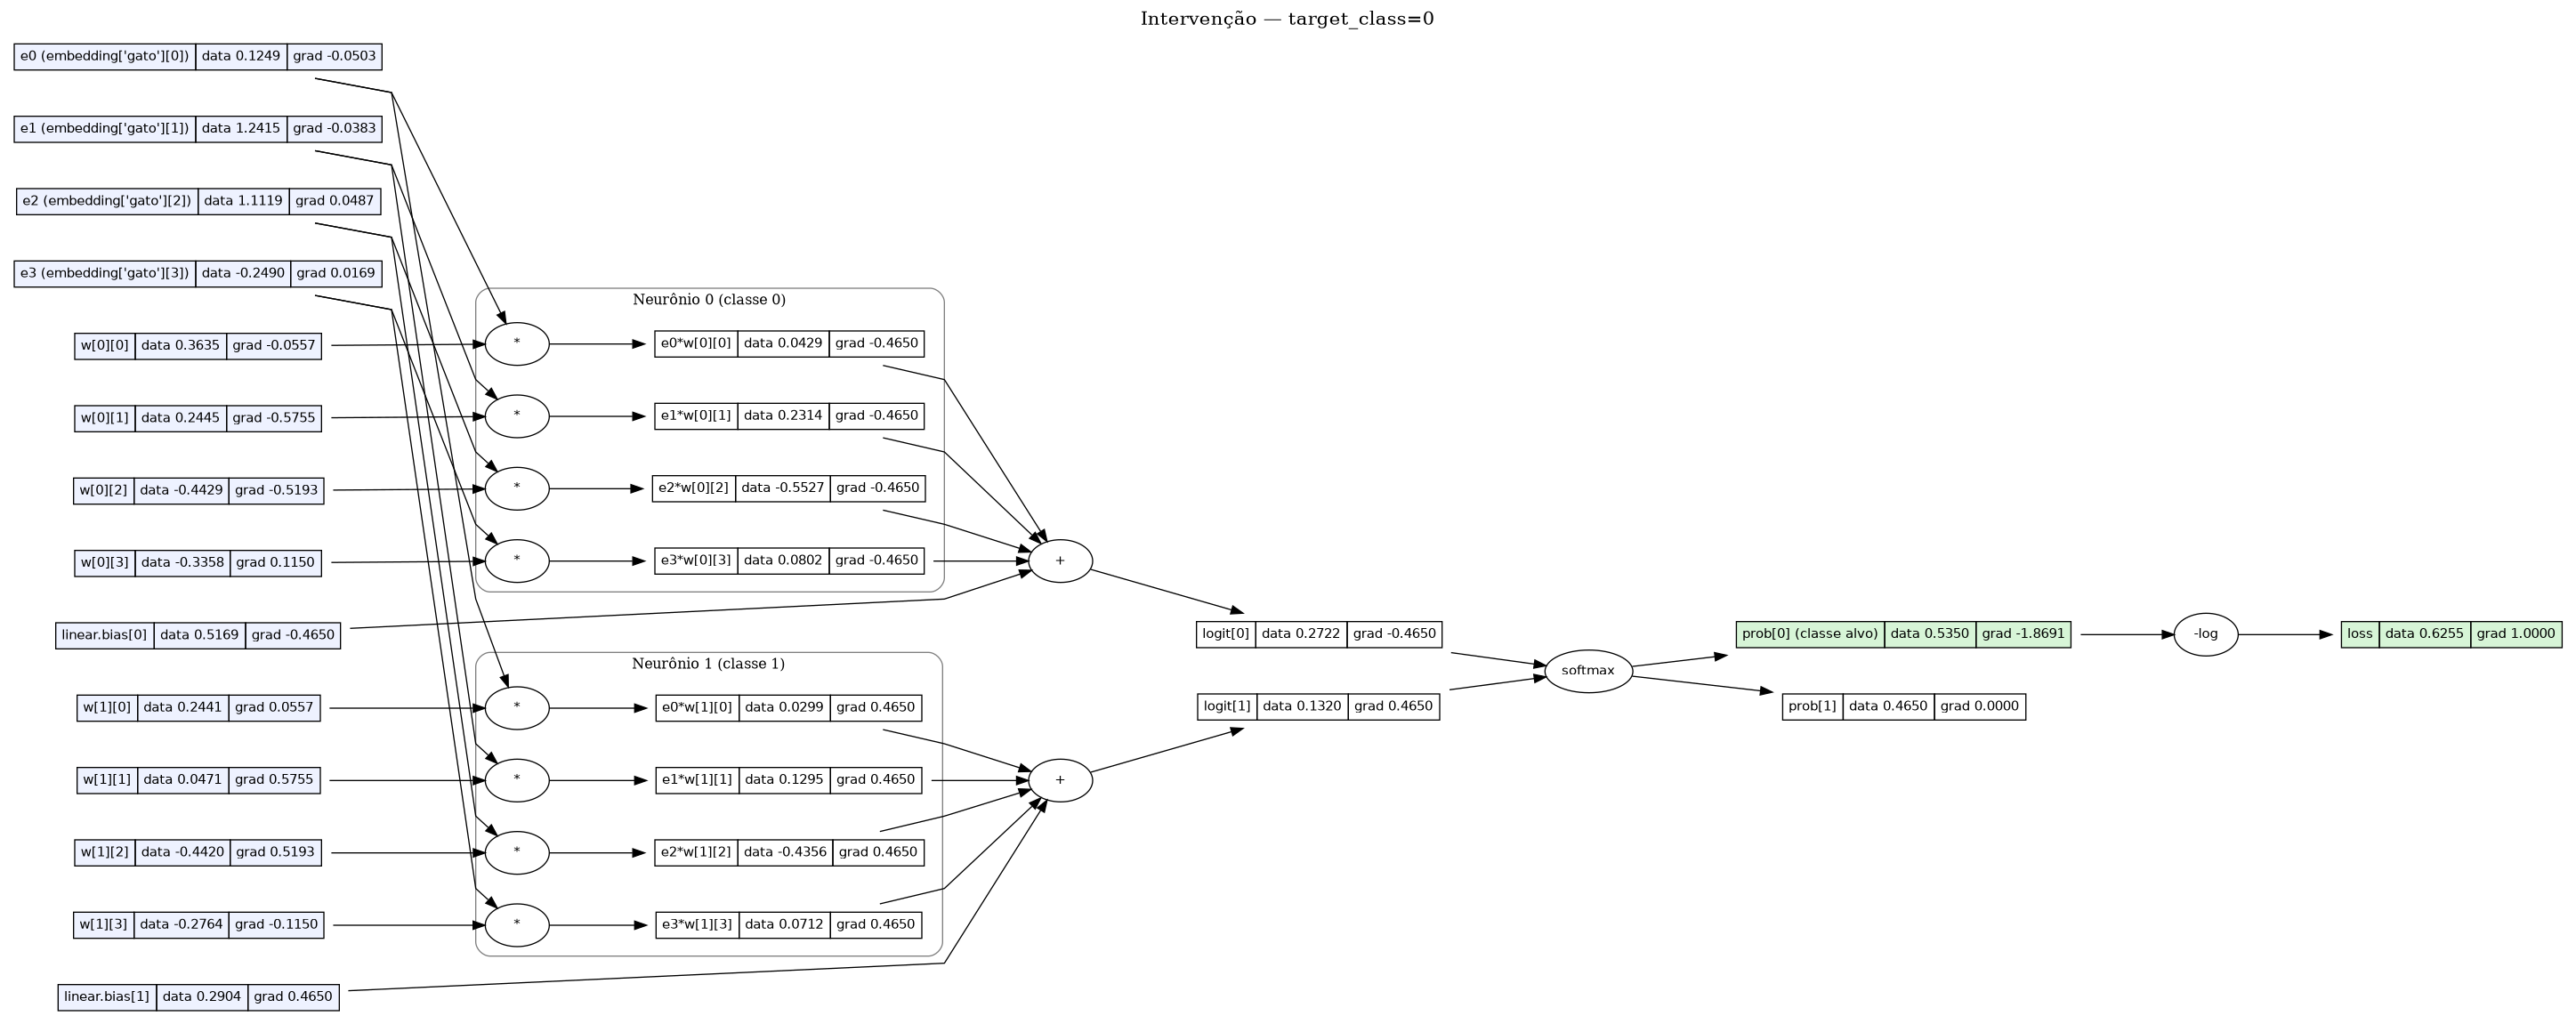

In [16]:
graph_intervencao = gradient_step_graph(intervened_result, stage='intervencao')
graph_intervencao

# Parte 3: exemplo prático — embeddings pré-treinados numa tarefa real

Treina CBOW no **mesmo corpus do classificador de sentimento** (não no
`TOY_CORPUS` de gato/cachorro, senão os vocabulários não bateriam) e usa a
tabela de embeddings resultante pra **inicializar** o classificador, em vez
de pesos aleatórios. É a mesma ideia por trás de usar word2vec/GloVe
prontos numa tarefa de classificação de texto.

As frases de sentimento são curtas (3-5 palavras), então usamos `window=1`
— com o `window=2` padrão quase nenhuma frase teria contexto suficiente
pra gerar um par de treino.

In [17]:
def pretrain_embeddings(embedding_dim=16):
    sentences = POSITIVE + NEGATIVE
    cbow_model, vocab = train_cbow(corpus=sentences, embedding_dim=embedding_dim, window=1)
    return cbow_model.embeddings.weight.detach().clone(), vocab


print("########## Pré-treinando embeddings com CBOW no corpus de sentimento ##########")
pretrained_weights, shared_vocab = pretrain_embeddings()

print("\n########## Classificador com embedding aleatório (baseline) ##########")
torch.manual_seed(0)
_, _, losses_random = train_sentiment_classifier(vocab=shared_vocab, verbose=False)

print("########## Classificador com embedding pré-treinado (CBOW) ##########")
torch.manual_seed(0)
_, _, losses_pretrained = train_sentiment_classifier(vocab=shared_vocab, pretrained_embedding=pretrained_weights, verbose=False)

print("\n########## Comparação da perda ao longo do treino ##########")
print(f"{'epoch':>6s}{'aleatório':>14s}{'pré-treinado':>16s}")
for epoch in sorted({1, 5, 10, 25, 50, 100, 200}):
    idx = epoch - 1
    print(f"{epoch:>6d}{losses_random[idx]:>14.4f}{losses_pretrained[idx]:>16.4f}")

########## Pré-treinando embeddings com CBOW no corpus de sentimento ##########
epoch   1 | loss 3.1601
epoch  50 | loss 0.1733
epoch 100 | loss 0.1733
epoch 150 | loss 0.1733
epoch 200 | loss 0.1733
epoch 250 | loss 0.1733
epoch 300 | loss 0.1733

########## Classificador com embedding aleatório (baseline) ##########
########## Classificador com embedding pré-treinado (CBOW) ##########

########## Comparação da perda ao longo do treino ##########
 epoch     aleatório    pré-treinado
     1        0.8510          0.8198
     5        0.7574          0.7069
    10        0.6836          0.6514
    25        0.5837          0.5793
    50        0.5048          0.4876
   100        0.3835          0.3446
   200        0.1971          0.1708


A versão pré-treinada tem perda menor em praticamente todas as épocas — o
embedding pré-treinado já carrega alguma noção de como as palavras se
relacionam (mesmo aprendida num corpus pequeno), então o classificador
converge mais rápido do que partindo de vetores aleatórios.